# Timeseries prediction

A timeseries can be any data obtained via measurements at regular intervals, like
the daily price of a stock, the hourly electricity consumption of a city, or the
weekly sales of a store.

Other examples : visitors to a website, a country’s GDP, or credit card transactions

Working with timeseries involves understanding the dynamics of a system—its periodic cycles, how it trends over time, its regular regime and its sudden spikes.

Most common timeseries related task is forecasting.

Forecast electricity consumption makes us well prepared to make supply-demand balanced.

Forecast revenue a few months in advance so that you can plan your budget.

Weather forecasting

Other useful applications:

Classification - Given a timeseries acitvity from a website, can we classify whether that is a human or bot ?

Anomaly detection - Can we detect anything unusual in a continous stream of activity ? on a corporate network ?

### Temperature forecasting

Given atmospheric pressure / humidity, can we predict temperature 24 hours in advance ?

Let's see if ANN / CNN has the capability to understand time series data - and we can progress to RNN

In [2]:
import os

In [31]:
fname = os.path.join("dataset/jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [4]:
for line in lines[0:10]:
    print(line)

print('\n')
print("Last record :", lines[-1])

01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.30
01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.10
01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.60
01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.00
01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.30
01.01.2009 01:00:00,996.50,-8.05,265.38,-8.78,94.40,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.70
01.01.2009 01:10:00,996.50,-7.62,265.81,-8.30,94.80,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.50
01.01.2009 01:20:00,996.50,-7.62,265.81,-8.36,94.40,3.44,3.25,0.19,2.03,3.26,1305.69,0.19,0.50,118.60
01.01.2009 01:30:00,996.50,-7.91,265.52,-8.73,93.80,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.50
01.01.2009 01:40:00,996.53,-8.43,264.99,-9.34,93.10,3.23,3.00,0.22,1.88,3.02,1309.

In [32]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    # We store column 1 in the temperature array.
    temperature[i] = values[1]
    # We store all columns (including the temperature) in the raw_data
    # array.
    raw_data[i, :] = values[:]

In [33]:
print(temperature.shape)
print(raw_data.shape)

(420451,)
(420451, 14)


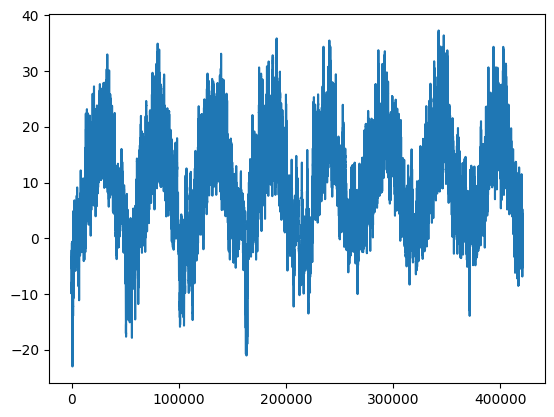

In [7]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

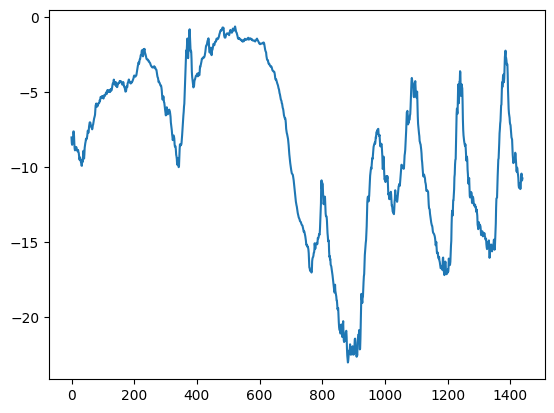

In [8]:
# plotting for first 10 days

plt.plot(range(1440), temperature[:1440]) # 24 * 6 - 144

### Important properties of timeseries data :

Daily periodicity - 
<pre>
	•	Website traffic peaks every day at 9 PM
	•	Electricity usage rises every morning at 7 AM
	•	Temperature increases every afternoon and drops at night
	•	Restaurant orders spike during lunch and dinner daily
	•	Heart rate patterns repeat every day
</pre>

### DO NOT shuffle timeseries data !!!

First 50% of the data for training, the following 25% for validation, and the last 25% for testing.

When working with timeseries data, be mindful of the fact that we are predicting future from the past.

In [9]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples

In [10]:
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


In [11]:
# normalizing the data - each timeseries in the data is of different scale

mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

### Understanding timeseries_dataset_from_array

In [12]:
import numpy as np
import keras

# Generate an array of sorted integers from 0 to 9.
int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    # The sequences we generate will be sampled from [0 1 2 3 4 5 6].
    data=int_sequence[:-3],
    # The target for the sequence that starts at data[N] will be data[N + 3].
    targets=int_sequence[3:],
    # The sequences will be 3 steps long.
    sequence_length=3,
    # The sequences will be batched in batches of size 2.
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


2025-11-29 12:33:20.270338: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### Explanation 

1)  Sampling_rate = 6

The dataset contains readings every 10 minutes.

If you pick every 6th reading:

6 × 10 minutes = 60 minutes = 1 hour

So we are sampling hourly data.

Converts 10-min intervals to hourly samples.

2)  sequence_length = 120

We want each input sample to contain 120 time steps.

Since each step = 1 hour (from sampling_rate):

120 hours = 5 days

So each training example contains 5 days of climate history.

Creates input windows covering 5 days of climate history.

3) delay = sampling_rate * (sequence_length + 24 - 1)

We want to predict temperature 24 hours into the future.

24 hours = 24 time steps

sequence_length = 120 time steps

For a given input sequence (5 days), the target is the temperature 24 hours later.

Input window (120 hours) ----------- gap (24 hours) ---> Target temp

delay = 6 * (120 + 24 - 1)
delay = 6 * 143
delay = 858

delay = 858 ensures the target is exactly 24 hours after the input window.

4) 

Train/val/test datasets are created by aligning raw_data (inputs) with temperature[delay:] (future targets), allowing the model to learn future temperature prediction.

5) Final notes

←────── 5 days (120 hrs) ──────→      ←─ 24 hrs ─→
[        INPUT WINDOW         ]  gap  [  TARGET  ]
t0                             t1     t2

The model sees data from t0 → t1 (120 time steps)

It predicts the temperature at t2 = t1 + 24 hours


In [13]:
import keras 

sampling_rate = 6
sequence_length = 120 
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

Each training sample uses 5 days of hourly climate data and predicts the temperature 24 hours after the end of that window. 

delay shifts the targets forward so that raw_data[:-delay] and temperature[delay:] line up as (past window → future temp) pairs.

In [14]:
# This takes one batch from the timeseries dataset and prints its shapes.
# Each batch contains 256 training examples.
# Each individual sample you get a 5-day window of climate data.
# At each time step, there are 14 features (e.g., temperature, pressure, humidity, wind, etc.)

# Batch of sequences: 256 time windows
# Each window: 120 time steps
# Each time step: 14 measurements

for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


In [15]:
for samples, targets in train_dataset:
    first_sample = samples[0]      # shape: (120, 14)
    first_target = targets[0]      # scalar
    break

In [34]:
print(first_sample)
print(first_target)

tf.Tensor(
[[-1.62717435  0.40407061  0.53069457 ... -0.61931536 -0.62007992
   1.01175483]
 [-1.5930772   0.39494963  0.51941502 ... -0.58019143 -0.60286122
   0.81024132]
 [-1.58837414  0.39038914  0.51377525 ... -0.99751341 -0.9988913
   0.83586731]
 ...
 [ 0.59266795 -0.19107359 -0.2363146  ... -0.93230685 -1.01611
  -1.61595813]
 [ 0.56562538 -0.18081248 -0.2239071  ... -1.16705047 -1.22273439
   1.94127961]
 [ 0.54916469 -0.23553838 -0.27804892 ... -0.75624914 -0.99028195
  -1.66942327]], shape=(120, 14), dtype=float64)
tf.Tensor(7.45, shape=(), dtype=float64)


In [35]:
jena_columns = [
    "p (mbar)",          # Air pressure
    "T (degC)",          # Temperature
    "Tpot (K)",          # Potential temperature
    "Tdew (degC)",       # Dew point temperature
    "rh (%)",            # Relative humidity
    "VPmax (mbar)",      # Saturation vapor pressure
    "VPact (mbar)",      # Actual vapor pressure
    "VPdef (mbar)",      # Vapor pressure deficit
    "sh (g/kg)",         # Specific humidity
    "H2OC (mmol/mol)",   # Water vapor concentration
    "rho (g/m**3)",      # Air density
    "wv (m/s)",          # Wind velocity
    "max. wv (m/s)",     # Maximum wind velocity
    "wd (deg)"           # Wind direction
]

In [36]:
for samples, targets in train_dataset:
    first_sample = samples[0].numpy()   # shape = (120, 14)
    first_target = targets[0].numpy()
    break

import pandas as pd

df = pd.DataFrame(first_sample, columns=jena_columns)

display(df)
print("Target temperature 24 hours later:", first_target)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,0.767857,-0.001813,-0.062610,0.468450,0.987880,-0.236236,0.307666,-0.646066,0.288476,0.290000,0.149336,-0.351968,0.240855,1.094457
1,0.806657,-0.049698,-0.113368,0.378056,0.903689,-0.278334,0.199151,-0.618810,0.182125,0.182849,0.207377,-0.065060,0.641190,1.222587
2,0.887785,-0.106704,-0.175405,0.205743,0.633074,-0.327010,0.003824,-0.524463,-0.015386,-0.014784,0.288967,0.026230,0.710065,1.881874
3,0.916003,-0.308506,-0.377309,-0.233516,0.151980,-0.487509,-0.432647,-0.400763,-0.448389,-0.448150,0.501863,-0.762770,-0.723392,0.911580
4,0.893664,-0.387175,-0.454010,-0.353570,0.091843,-0.546709,-0.538750,-0.402859,-0.550943,-0.550538,0.574176,-0.762770,-0.559814,1.108435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,1.022998,0.262695,0.179901,0.685961,0.711252,0.015037,0.587393,-0.486724,0.558154,0.561449,-0.037870,-0.938828,-0.861142,-0.905536
116,1.034755,0.223931,0.140422,0.674662,0.801457,-0.024430,0.570513,-0.534946,0.542961,0.544781,0.000427,-0.867100,-0.964454,1.163181
117,1.053567,0.185167,0.100944,0.637939,0.831525,-0.062581,0.522284,-0.553815,0.497382,0.497158,0.042055,-1.121406,-0.998891,-0.517651
118,1.071204,0.147543,0.061465,0.608279,0.873621,-0.099417,0.483701,-0.578974,0.455600,0.459060,0.082018,-1.004034,-1.084985,-0.734307


Target temperature 24 hours later: 9.43


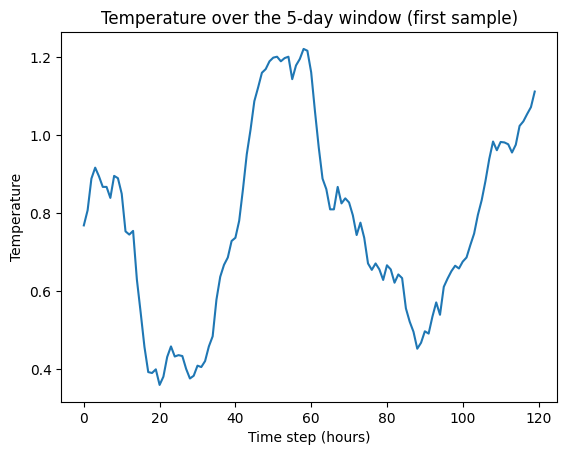

In [37]:
import matplotlib.pyplot as plt

plt.plot(first_sample[:, 0])  # assuming col 0 = temperature
plt.title("Temperature over the 5-day window (first sample)")
plt.xlabel("Time step (hours)")
plt.ylabel("Temperature")
plt.show()

In [17]:
# Let's try with simple ANN

import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    # We use a callback to save the best-performing model.
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

# Reloads the best model and evaluates it on the test data
model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 12.4565 - mae: 2.7013 - val_loss: 10.7157 - val_mae: 2.5926
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.9863 - mae: 2.2230 - val_loss: 10.6798 - val_mae: 2.5966
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 7.2650 - mae: 2.1191 - val_loss: 11.4294 - val_mae: 2.6853
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.8655 - mae: 2.0562 - val_loss: 10.7701 - val_mae: 2.6009
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.5718 - mae: 2.0109 - val_loss: 11.0647 - val_mae: 2.6277
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.4297 - mae: 1.9885 - val_loss: 11.4288 - val_mae: 2.6746
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.2350 - mae: 1.9583 - val_loss: 11.5339 - val_mae: 2.6811
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 6.0881 - mae: 1.9351 - val_loss: 11.6093 - val_mae: 2.6927
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/

(batch_size, 120, 14) gets Flattened to (batch_size, 1680)

inputs preserves the time series structure

Flatten() removes the time axis and treats the whole thing like one long vector

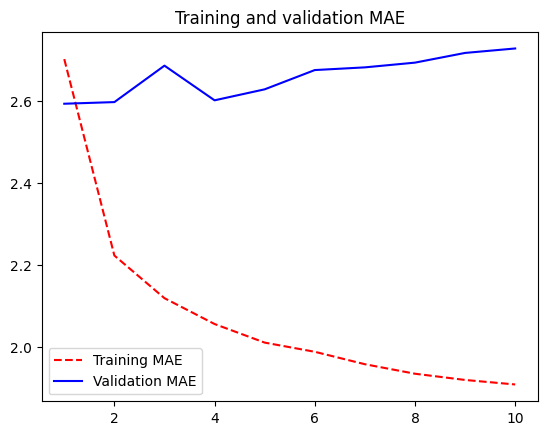

In [18]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Let's try with 1D Convolutional model

In [19]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)

outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10


819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 23.5464 - mae: 3.7463 - val_loss: 14.4631 - val_mae: 3.0193
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 14.2269 - mae: 2.9940 - val_loss: 14.0404 - val_mae: 2.9618
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 12.9767 - mae: 2.8516 - val_loss: 13.5220 - val_mae: 2.9071
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 12.0925 - mae: 2.7492 - val_loss: 13.8090 - val_mae: 2.9381
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 11.3427 - mae: 2.6625 - val_loss: 13.1509 - val_mae: 2.8697
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 10.6905 - mae: 2.5853 - val_loss: 13.4070 - val_mae: 2.8935
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 10.2211 - mae: 2.5291 - val_loss: 13.7973 - val_mae: 2.9302
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 9.7832 - mae: 2.4729 - val_loss: 13.8827 - val_mae: 2.9467
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step

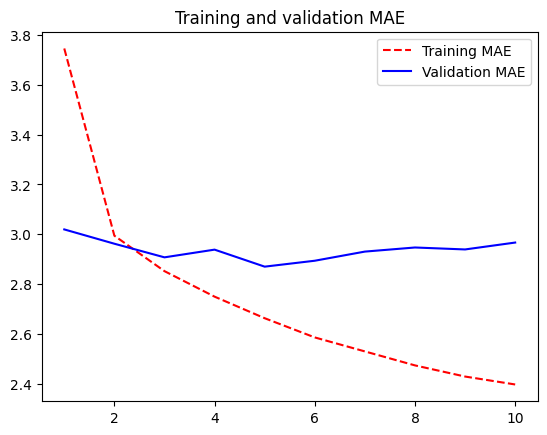

In [20]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Why ANN / 1D is not helping ?

First, weather data doesn’t quite respect the translation invariance assumption. 

While the data does feature daily cycles, data from a morning follows different properties than data from an evening or from the middle of the night. Weather data is only translation-invariant for a very specific timescale.


Second, order in our data matters — a lot. 

The recent past is far more informative for predicting the next day’s temperature than data from five days ago. 

A 1D ConvNet is not able to make use of this fact. In particular, our max pooling and global average pooling layers are largely destroying order information.

# Recurrent Neural Network

### Drawbacks of feedforward network

A major characteristic of all neural networks you’ve seen so far, such as densely connected networks and ConvNets, is that they have no memory.

Each input shown to them is processed independently, with no state kept between inputs.

With such networks, to process a sequence or a temporal series of data points, you have to show the entire sequence to the network at once : turn it into a single data point.

We flattened our five days of data into a single large vector and processed it in one go. Such networks are called feedforward networks.

In [21]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
print(inputs)
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

<KerasTensor shape=(None, 120, 14), dtype=float32, sparse=False, ragged=False, name=keras_tensor_32>
Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - loss: 45.1243 - mae: 4.9540 - val_loss: 17.4623 - val_mae: 3.1203
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 14.4867 - mae: 2.8911 - val_loss: 11.5107 - val_mae: 2.6002
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 11.3926 - mae: 2.6166 - val_loss: 10.2176 - val_mae: 2.4769
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 10.4084 - mae: 2.5119 - val_loss: 9.9465 - val_mae: 2.4459
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 9.8443 - mae: 2.4459 - val_loss: 9.8905 - val_mae: 2.4413
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 9.4015 - mae: 2.3891 - val_loss: 10.5131 - val_mae: 2.5267
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - loss: 9.2806 - mae: 2.3705 - val_loss: 9.4997 - val_mae: 2.4018
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/st

In [22]:
model = keras.models.load_model("jena_lstm.keras")
print("Test MAE", model.evaluate(test_dataset))

405/405 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 10.7058 - mae: 2.5606
Test MAE [10.705798149108887, 2.560607671737671]


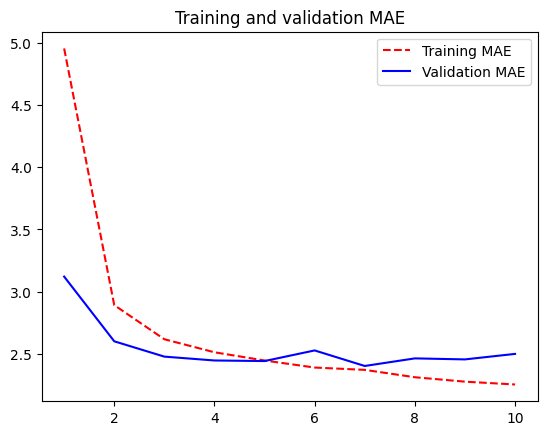

In [23]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

### Understanding Recurrent Neural Networks

In effect, an RNN is a type of neural network that has an internal loop.

Imagine reading a sentence and you try to predict the next word, you don’t rely only on the current word but also remember the words that came before. 

RNNs work similarly by “remembering” past information and passing the output from one step as input to the next i.e it considers all the earlier words to choose the most likely next word. 

This memory of previous steps helps the network understand context and make better predictions.

<img src="./images/dl_rnn_1.png" />

<img src="./images/dl_rnn_2.png" />

RNN processes
sequences by iterating through the sequence elements and
maintaining a state that contains information relative to what
Recurrent
connection
it has seen so far. 

In effect, an RNN is a type of neural network that has an internal loop.

The state of the RNN is reset between processing two different, independent sequences (such as two samples in a
batch), so you still consider one sequence to be a single data
point: a single input to the network. 

What changes is that this
data point is no longer processed in a single step; rather, the
network internally loops over sequence elements.

The fundamental processing unit in RNN is a Recurrent Unit. They hold a hidden state that maintains information about previous inputs in a sequence. Recurrent units can "remember" information from prior steps by feeding back their hidden state, allowing them to capture dependencies across time.

<img src="./images/dl_rnn_3.png" />

u - input weight matrix

v - recurrent weight matrix

w - output weight matrix

These are learnable parameters — they get updated during training.

### Psuedocode for RNN
<pre>
state_t = 0
for input_t in input_sequence:
    output_t = activation(dot(W, input_t) + dot(U, state_t) + b)
    state_t = output_ts
</pre>

### How to build SimpleRNN layers in Keras

In [24]:
num_features = 14
steps = 120

inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)

print(outputs.shape)


(None, 120, 16)


SimpleRNN has a major issue: although it should theoretically
be able to retain at time t information about inputs seen many timesteps before, such
long-term dependencies prove impossible to learn in practice. 

This is due to the <b> vanishing gradient problem </b>, an effect that is similar to what is observed with non-recurrent net-
works (feedforward networks) that are many layers deep: as you keep adding layers to a
network, the network eventually becomes untrainable

<img src="./images/dl_rnn_4.png" />

### LSTM 

It saves information for later,
thus preventing older signals from gradually vanishing during processing

<img src="./images/dl_rnn_5.png" />

### Advanced techniques

Recurrent dropout

Stacking recurrent layers

Bidirectional recurrent layers

##### Recurrent dropout

In [25]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)

In [26]:
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

In [27]:
callbacks = [
keras.callbacks.ModelCheckpoint("jena_lstm_dropout.keras",
save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
epochs=50,
validation_data=val_dataset,
callbacks=callbacks)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - loss: 28.4078 - mae: 3.9324 - val_loss: 9.5694 - val_mae: 2.4037
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - loss: 14.9960 - mae: 3.0087 - val_loss: 9.1587 - val_mae: 2.3576
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - loss: 14.3857 - mae: 2.9454 - val_loss: 9.0898 - val_mae: 2.3457
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 13.9358 - mae: 2.8950 - val_loss: 8.9442 - val_mae: 2.3230
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 13.5675 - mae: 2.8552 - val_loss: 8.9696 - val_mae: 2.3221
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 13.2521 - mae: 2.8221 - val_loss: 8.9503 - val_mae: 2.3170
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 12.8283 - mae: 2.7774 - val_loss: 8.9749 - val_mae: 2.3146
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 28s 34ms/step - loss: 12.4872 - mae: 2.7406 - val_loss: 8.9308 - val_mae: 2.3052
Epoch 9/50
819/819 ━━━━━━━━━━━━━

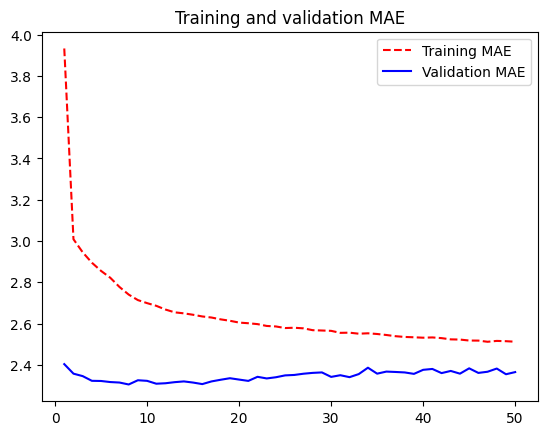

In [28]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

##### Stacking recurrent layers

Recurrent layer stacking is a classic way to build
more-powerful recurrent networks.

GRU
is very similar to LSTM—you can think of it as a slightly simpler, streamlined version of
the LSTM architecture

In [ ]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)
callbacks = [
keras.callbacks.ModelCheckpoint("jena_stacked_gru_dropout.keras",
save_best_only=True)
]
model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
history = model.fit(train_dataset,
epochs=50,
validation_data=val_dataset,
callbacks=callbacks)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

<img src="./images/dl_rnn_6.png" />

##### Bidirectional RNNs

RNNs are notably order-dependent: they process the timesteps of their input
sequences in order, and shuffling or reversing the timesteps can completely change
the representations the RNN extracts from the sequence.

A bidirectional RNN exploits the order sensitivity of RNNs: 

It
uses two regular RNNs, such as the GRU and LSTM layers you’re already familiar with,
each of which processes the input sequence in one direction (chronologically and
antichronologically), and then merges their representations. 

By processing a sequence
both ways, a bidirectional RNN can catch patterns that may be overlooked by a unidi-
rectional RNN.

<img src="./images/dl_rnn_7.png" />

In [29]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))

x = layers.Bidirectional(layers.LSTM(16))(inputs)

outputs = layers.Dense(1)(x)

model = keras.Model(inputs, outputs)

model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

history = model.fit(train_dataset,
    epochs=10,
    validation_data=val_dataset
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 24.2103 - mae: 3.5416 - val_loss: 10.6470 - val_mae: 2.5324
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 9.4120 - mae: 2.3943 - val_loss: 9.8039 - val_mae: 2.4300
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 8.5058 - mae: 2.2722 - val_loss: 10.1077 - val_mae: 2.4728
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 8.0122 - mae: 2.2032 - val_loss: 10.1790 - val_mae: 2.4863
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 7.6610 - mae: 2.1567 - val_loss: 10.0784 - val_mae: 2.4775
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 7.3270 - mae: 2.1089 - val_loss: 10.6745 - val_mae: 2.5461
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 7.0372 - mae: 2.0662 - val_loss: 10.4560 - val_mae: 2.5249
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - loss: 6.8438 - mae: 2.0348 - val_loss: 11.0015 - val_mae: 2.5868
Epoch 9/10
819/819 ━━━━━━━━━━━━━

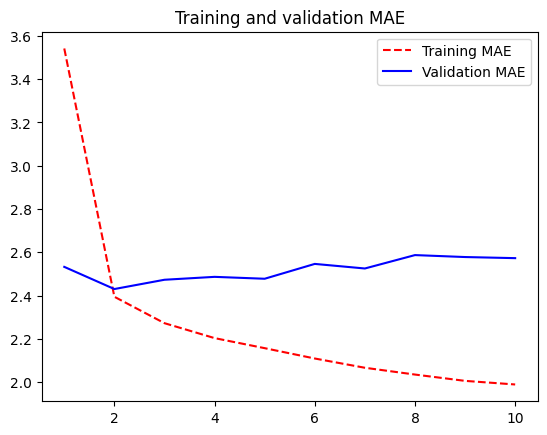

In [30]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

You’ll find that it doesn’t perform as well as the plain LSTM layer. It’s easy to under-
stand why: all the predictive capacity must come from the chronological half of the
network, because the antichronological half is known to be severely underperforming
on this task.

Bidirectional RNNs are a great fit for text data.

In fact, for a while
in 2016, bidirectional LSTMs were considered the state of the art on many natural lan-
guage processing tasks (before the rise of the Transformer architecture)